## Homework 1 - Phase I & II Analysis Using Shewhart $\bar{X}$ and R/s Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: September 19, 2026 via D2L**

## Instructions:

A company called Blue Ridge Filament Co (BRFC) manufactures 1.75 mm PLA filament for 3D printers, selling to both hobbyist and small-manufacturing customers. Over the last quarter, customer support tickets describing clogging, stringing, and inconsistent print layers have risen sharply, and BRFC recently lost a wholesale account to a competitor over “inconsistent quality.” The plant manager has asked your quality control team to investigate Extruder Line 3, the line most frequently named in the complaint data, and to determine whether the line is running in a state of statistical control. This line is about six months away from needing its heating element replaced, but it could be replaced sooner if necessary.

The plant manager is particularly interested in the filament diameter produced (mm), measured inline by a laser micrometer as each spool is produced. Diameter that runs too thin causes under-extrusion and stringing; diameter that runs too thick causes jams and clogs in customers' print heads. Filament diameter is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of production data from Line 3: 5 spools sampled at random each week, for 25 consecutive weeks. After validating statistical control and process capability, the team can establish an ongoing monitoring plan for Phase II analysis.

## Key Specifications

| Quantity | Value |
|---|---|
| Target diameter | 1.750 mm |
| Lower Specification Limit (LSL) | 1.700 mm |
| Upper Specification Limit (USL) | 1.800 mm |
| Subgroup size (n) | 5 spools per week |
| Phase I subgroups (m) | 25 weeks |
| Phase II subgroups | 20 weeks |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis
The Purpose of this analysis is to understand whether the extruder line 3 is running out of control an is the cause of the defects mentioned in the complaints by the client.

### Q2: Identify the quality characteristic your team will monitor, classify its units and measurement scale.

Our team will be monitoring the diameter of the filament which is considered a critical to quality according to the design.

Units:.000 mm

Scale: 1.700 - 1.800mm

Target: 1.750 mm

### Q3: Briefly describe why a Shewhart $\bar{X}$ and $R/s$ chart would be appropriate in this scenario. What are its limitations?

Its mainly used for continous variables to monitor the tendency and variability of a process over time

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the estimated process mean and standard deviation using both the $R$ and $s$ methods.

Estimated mean =  1.7540173912604298
Estimated standard deviation R methd =  0.01144863942827493

Estimated mean =  1.7540173912604298
Estimated standard deviation S method =  0.01154485067870555


In [26]:
## Q4 Code ##
# I Tried doing it in R but failed#

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('/content/FilamentDiameter_PhaseI.xlsx')

print(df)

measurements = df[["Meas1","Meas2", "Meas3", "Meas4", "Meas5"]]
#Get the mean for each subgroup(1-25)
Xbar = measurements.mean(axis = 1)
print(Xbar)

#Range of each subgroup
R = measurements.max(axis = 1) - measurements.min(axis = 1)
print(R)

#Sample standard deviation of each subgroup
s = measurements.std(axis = 1, ddof= 1)
print(s)

#Overall Averages#
grandmean = Xbar.mean()
print(grandmean)
R_bar = R.mean()
s_bar = s.mean()






    Subgroup     Meas1     Meas2     Meas3     Meas4     Meas5
0          1  1.759712  1.742690  1.771452  1.758564  1.755669
1          2  1.752064  1.733264  1.767347  1.761277  1.744550
2          3  1.755094  1.745186  1.753372  1.763998  1.745075
3          4  1.763434  1.746130  1.747787  1.747608  1.748262
4          5  1.751915  1.757228  1.745419  1.755608  1.742620
5          6  1.746336  1.769405  1.752795  1.750858  1.737254
6          7  1.748402  1.762983  1.753441  1.757831  1.763623
7          8  1.742936  1.744810  1.756836  1.742607  1.764783
8          9  1.757197  1.756742  1.748131  1.761140  1.747708
9         10  1.763309  1.750564  1.743802  1.759731  1.740353
10        11  1.770796  1.742359  1.745838  1.753425  1.736433
11        12  1.808590  1.801366  1.806513  1.808711  1.798939
12        13  1.746095  1.771719  1.743757  1.758282  1.737854
13        14  1.750101  1.739903  1.718383  1.759310  1.752742
14        15  1.761994  1.749148  1.751662  1.751595  1

In [15]:
import math
#R Method
d2 = 2.326

sigma_R = R_bar / d2

print("Estimated mean = ", grandmean)
print("Estimated standard deviation R methd = ", sigma_R)

#S Method

n = 5

c4 = np.sqrt(2/ (n-1)) * math.gamma(n/2)/ math.gamma((n-1)/2) # For this i needed ai help

sigma_s = s_bar / c4

print("c4 = ", c4)
print("Estimated mean = ", grandmean)
print("Estimated standard deviation S method = ", sigma_s)



Estimated mean =  1.7540173912604298
Estimated standard deviation R methd =  0.01144863942827493
c4 =  0.9399856029866254
Estimated mean =  1.7540173912604298
Estimated standard deviation S method =  0.01154485067870555



### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.
Incorrect. According to the content teached in class one single point outside of the limits is considered out of control. The spread for the subgroup 19 is bigger in comparison to the rest. That subgroup contains the lowest measurement on the study.

R-bar: 0.026630
UCL: 0.056295
LCL: 0.000000


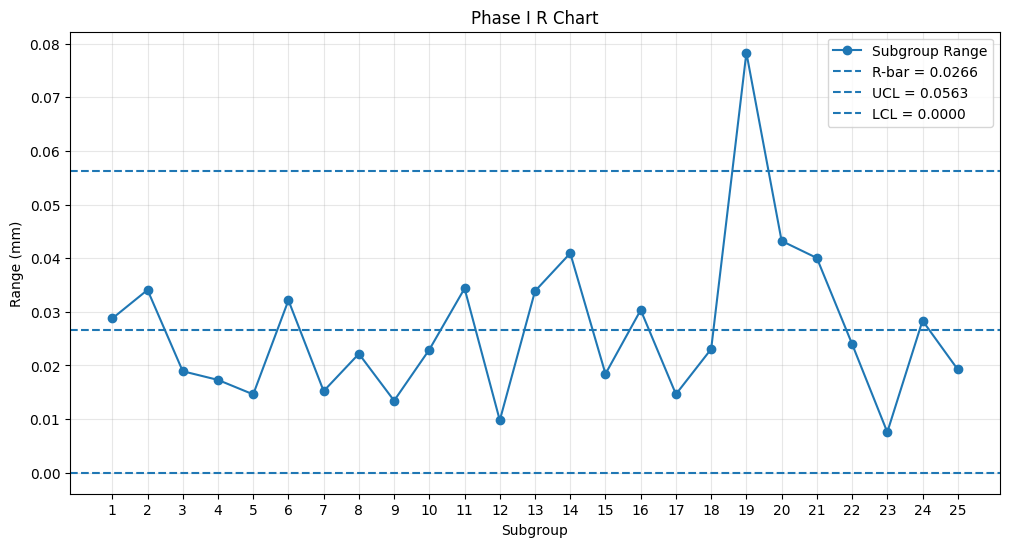

In [19]:
## Q5 Code ##

import numpy as np
import matplotlib.pyplot as plt

# Measurement columns
measure_cols = ["Meas1", "Meas2", "Meas3", "Meas4", "Meas5"]

# Calculate range for each subgroup
df["R"] = df[measure_cols].max(axis=1) - df[measure_cols].min(axis=1)

# R-chart constants for n = 5
D3 = 0
D4 = 2.114

# Calculate center line and control limits
R_bar = df["R"].mean()
UCL_R = D4 * R_bar
LCL_R = D3 * R_bar

print(f"R-bar: {R_bar:.6f}")
print(f"UCL: {UCL_R:.6f}")
print(f"LCL: {LCL_R:.6f}")

plt.figure(figsize=(12, 6))

plt.plot(
    df["Subgroup"],
    df["R"],
    marker="o",
    label="Subgroup Range"
)

plt.axhline(R_bar, linestyle="--", label=f"R-bar = {R_bar:.4f}")
plt.axhline(UCL_R, linestyle="--", label=f"UCL = {UCL_R:.4f}")
plt.axhline(LCL_R, linestyle="--", label=f"LCL = {LCL_R:.4f}")


plt.xlabel("Subgroup")
plt.ylabel("Range (mm)")
plt.title("Phase I R Chart")
plt.xticks(df["Subgroup"])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

New R-bar: 0.024476
New UCL: 0.051743
New LCL: 0.000000

Remaining OOC subgroups:
Empty DataFrame
Columns: [Subgroup, R]
Index: []


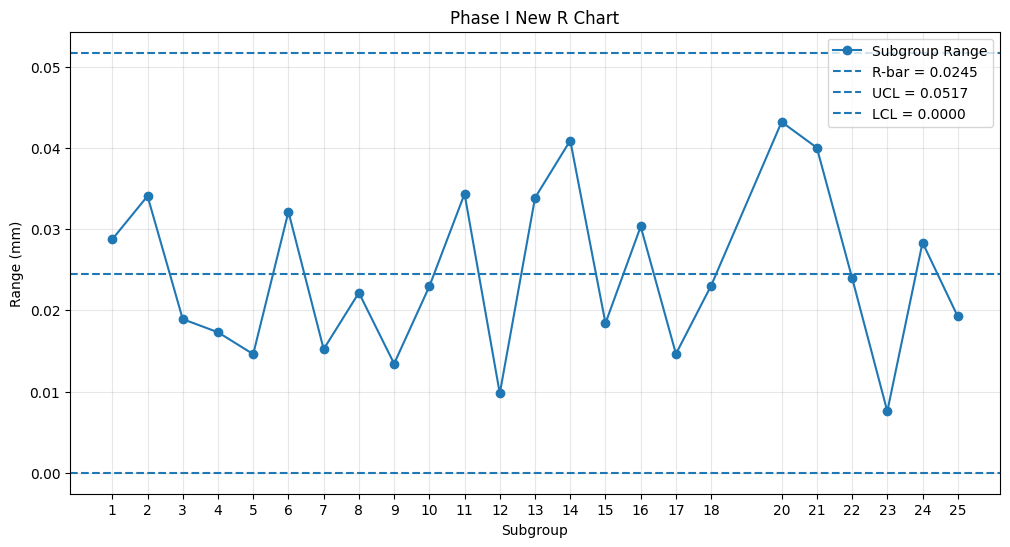

In [22]:
#Q5 Part II
# Remove subgroup 19
df_control = df[df["Subgroup"] != 19].copy()

# Recalculate R chart limits
R_bar_new = df_control["R"].mean()
UCL_R_new = D4 * R_bar_new
LCL_R_new = D3 * R_bar_new

print(f"New R-bar: {R_bar_new:.6f}")
print(f"New UCL: {UCL_R_new:.6f}")
print(f"New LCL: {LCL_R_new:.6f}")

# Check again for OOC points
ooc_new = df_control[
    (df_control["R"] > UCL_R_new) |
    (df_control["R"] < LCL_R_new)
]

print("\nRemaining OOC subgroups:")
print(ooc_new[["Subgroup", "R"]])


plt.figure(figsize=(12, 6))

plt.plot(
    df_control["Subgroup"],
    df_control["R"],
    marker="o",
    label="Subgroup Range"
)

plt.axhline(
    R_bar_new,
    linestyle="--",
    label=f"R-bar = {R_bar_new:.4f}"
)

plt.axhline(
    UCL_R_new,
    linestyle="--",
    label=f"UCL = {UCL_R_new:.4f}"
)

plt.axhline(
    LCL_R_new,
    linestyle="--",
    label=f"LCL = {LCL_R_new:.4f}"
)

plt.xlabel("Subgroup")
plt.ylabel("Range (mm)")
plt.title("Phase I New R Chart")
plt.xticks(df_control["Subgroup"])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

The chart does not show evidene of statistical control, again even for one single subgroup to be outside of the limits is considered out of control. The subgroup out of control is the number 12. The subgroup 12 is out of control due to it averaging 1.8mm while the estimated mean is ~1.75mm

X-double-bar: 1.753618
R-bar: 0.024476
UCL: 1.767741
LCL: 1.739496

Out-of-control subgroups:
    Subgroup      Xbar
11        12  1.804824


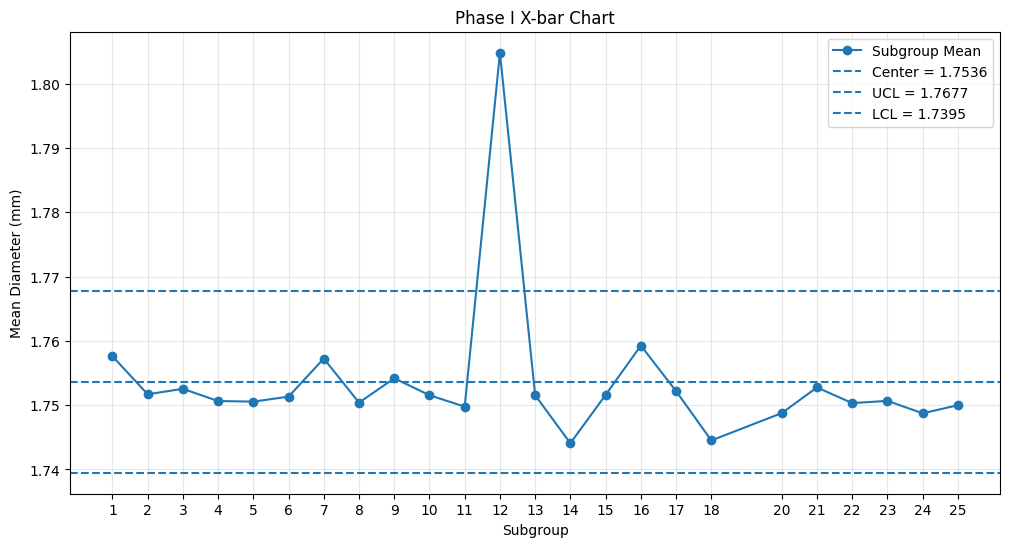

In [25]:
## Q6 Code ##

# We already removed subgroup 19 in Q5
df_control = df[df["Subgroup"] != 19].copy()

measure_cols = ["Meas1", "Meas2", "Meas3", "Meas4", "Meas5"]

# Calculate subgroup means
df_control["Xbar"] = df_control[measure_cols].mean(axis=1)

# Recalculate subgroup ranges
df_control["R"] = (
    df_control[measure_cols].max(axis=1)
    - df_control[measure_cols].min(axis=1)
)

# Constants for n = 5
A2 = 0.577

# Center line and control limits
X_double_bar = df_control["Xbar"].mean()
R_bar = df_control["R"].mean()

UCL_X = X_double_bar + A2 * R_bar
LCL_X = X_double_bar - A2 * R_bar

print(f"X-double-bar: {X_double_bar:.6f}")
print(f"R-bar: {R_bar:.6f}")
print(f"UCL: {UCL_X:.6f}")
print(f"LCL: {LCL_X:.6f}")

# Find out-of-control subgroups
ooc = df_control[
    (df_control["Xbar"] > UCL_X) |
    (df_control["Xbar"] < LCL_X)
]

print("\nOut-of-control subgroups:")
print(ooc[["Subgroup", "Xbar"]])

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    df_control["Subgroup"],
    df_control["Xbar"],
    marker="o",
    label="Subgroup Mean"
)

plt.axhline(
    X_double_bar,
    linestyle="--",
    label=f"Center = {X_double_bar:.4f}"
)

plt.axhline(
    UCL_X,
    linestyle="--",
    label=f"UCL = {UCL_X:.4f}"
)

plt.axhline(
    LCL_X,
    linestyle="--",
    label=f"LCL = {LCL_X:.4f}"
)

plt.xlabel("Subgroup")
plt.ylabel("Mean Diameter (mm)")
plt.title("Phase I X-bar Chart")
plt.xticks(df_control["Subgroup"])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

New X-double-bar: 1.751392
New R-bar: 0.025115
New UCL: 1.765884
New LCL: 1.736900


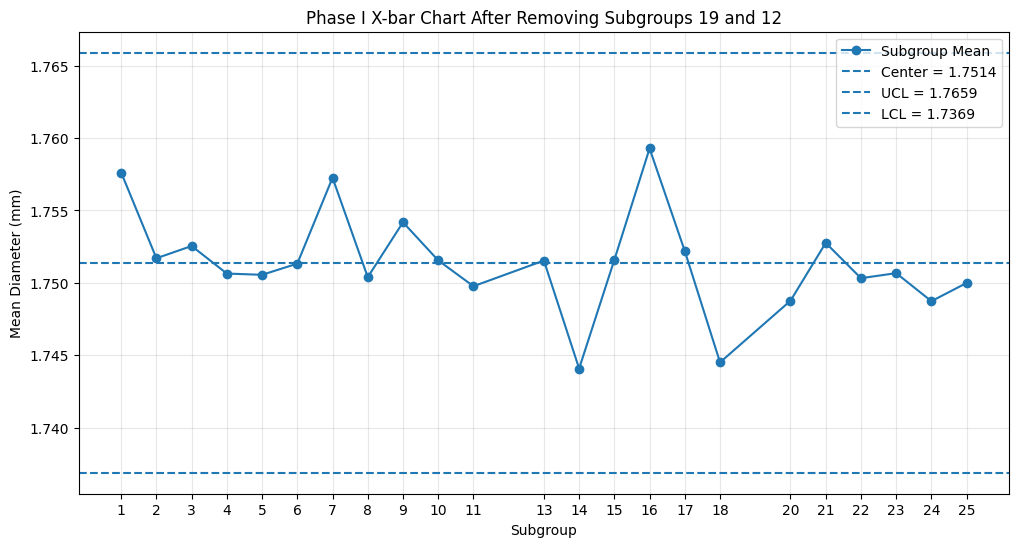

In [29]:
# Q6 Part II

# Remove subgroup 12
df_final = df_control[df_control["Subgroup"] != 12].copy()

# Recalculate statistics
X_double_bar_new = df_final["Xbar"].mean()
R_bar_new = df_final["R"].mean()

UCL_X_new = X_double_bar_new + A2 * R_bar_new
LCL_X_new = X_double_bar_new - A2 * R_bar_new

print(f"New X-double-bar: {X_double_bar_new:.6f}")
print(f"New R-bar: {R_bar_new:.6f}")
print(f"New UCL: {UCL_X_new:.6f}")
print(f"New LCL: {LCL_X_new:.6f}")

plt.figure(figsize=(12, 6))

plt.plot(
    df_final["Subgroup"],
    df_final["Xbar"],
    marker="o",
    label="Subgroup Mean"
)

plt.axhline(
    X_double_bar_new,
    linestyle="--",
    label=f"Center = {X_double_bar_new:.4f}"
)

plt.axhline(
    UCL_X_new,
    linestyle="--",
    label=f"UCL = {UCL_X_new:.4f}"
)

plt.axhline(
    LCL_X_new,
    linestyle="--",
    label=f"LCL = {LCL_X_new:.4f}"
)

plt.xlabel("Subgroup")
plt.ylabel("Mean Diameter (mm)")
plt.title("Phase I X-bar Chart After Removing Subgroups 19 and 12")
plt.xticks(df_final["Subgroup"])
plt.legend()
plt.grid(alpha=0.3)

plt.show()


### Q7: Repeat the same process in Q4 - Q6 now using the $s$ chart instead of the $R$ chart

In [30]:
## Q7 Code ##
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import gamma, sqrt

# Subgroup size
n = len(measure_cols)

# Subgroup means
df["Xbar"] = df[measure_cols].mean(axis=1)

# Subgroup sample standard deviations
df["s"] = df[measure_cols].std(axis=1, ddof=1)

# c4 constant calculated from n
c4 = sqrt(2 / (n - 1)) * gamma(n / 2) / gamma((n - 1) / 2)

# Estimates
X_double_bar = df["Xbar"].mean()
s_bar = df["s"].mean()
sigma_s = s_bar / c4

print(f"Process mean: {X_double_bar:.6f}")
print(f"s-bar: {s_bar:.6f}")
print(f"Estimated process SD using s method: {sigma_s:.6f}")

Process mean: 1.754017
s-bar: 0.010852
Estimated process SD using s method: 0.011545


In [31]:
# s-chart constants
B3 = max(0, 1 - 3 * sqrt(1 - c4**2) / c4)
B4 = 1 + 3 * sqrt(1 - c4**2) / c4

# Control limits
CL_s = s_bar
UCL_s = B4 * s_bar
LCL_s = B3 * s_bar

# Find OOC points
ooc_s = df[
    (df["s"] > UCL_s) |
    (df["s"] < LCL_s)
]

print(f"B3: {B3:.4f}")
print(f"B4: {B4:.4f}")
print(f"s-bar: {CL_s:.6f}")
print(f"UCL: {UCL_s:.6f}")
print(f"LCL: {LCL_s:.6f}")

print("\nOut-of-control subgroups:")
print(ooc_s[["Subgroup", "s"]])

B3: 0.0000
B4: 2.0890
s-bar: 0.010852
UCL: 0.022670
LCL: 0.000000

Out-of-control subgroups:
    Subgroup         s
18        19  0.037602


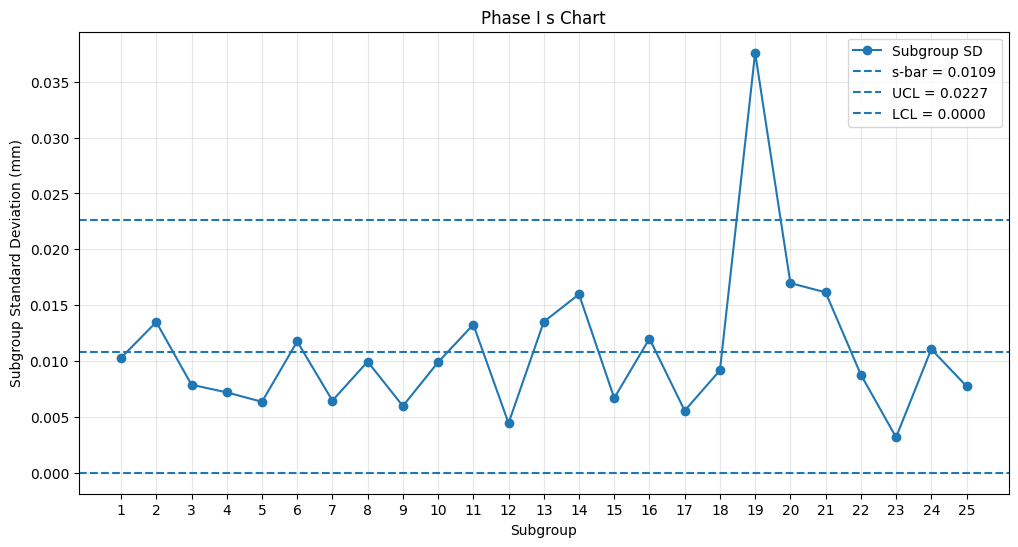

In [33]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["Subgroup"],
    df["s"],
    marker="o",
    label="Subgroup SD"
)

plt.axhline(CL_s, linestyle="--", label=f"s-bar = {CL_s:.4f}")
plt.axhline(UCL_s, linestyle="--", label=f"UCL = {UCL_s:.4f}")
plt.axhline(LCL_s, linestyle="--", label=f"LCL = {LCL_s:.4f}")



plt.xlabel("Subgroup")
plt.ylabel("Subgroup Standard Deviation (mm)")
plt.title("Phase I s Chart")
plt.xticks(df["Subgroup"])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

New s-bar: 0.009737
New UCL: 0.020341
New LCL: 0.000000

Remaining OOC:
Empty DataFrame
Columns: [Subgroup, s]
Index: []


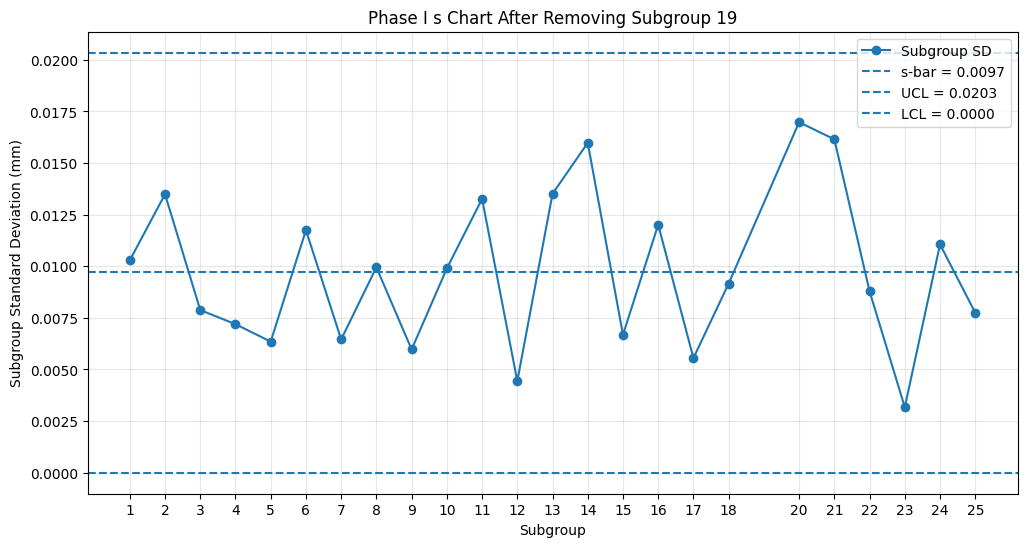

In [35]:
#Part II Q7

df_s_control = df[df["Subgroup"] != 19].copy()

# Recalculate s-bar and limits
s_bar_new = df_s_control["s"].mean()

UCL_s_new = B4 * s_bar_new
LCL_s_new = B3 * s_bar_new

# Check again
ooc_s_new = df_s_control[
    (df_s_control["s"] > UCL_s_new) |
    (df_s_control["s"] < LCL_s_new)
]

print(f"New s-bar: {s_bar_new:.6f}")
print(f"New UCL: {UCL_s_new:.6f}")
print(f"New LCL: {LCL_s_new:.6f}")

print("\nRemaining OOC:")
print(ooc_s_new[["Subgroup", "s"]])

plt.figure(figsize=(12, 6))

plt.plot(
    df_s_control["Subgroup"],
    df_s_control["s"],
    marker="o",
    label="Subgroup SD"
)

plt.axhline(
    s_bar_new,
    linestyle="--",
    label=f"s-bar = {s_bar_new:.4f}"
)

plt.axhline(
    UCL_s_new,
    linestyle="--",
    label=f"UCL = {UCL_s_new:.4f}"
)

plt.axhline(
    LCL_s_new,
    linestyle="--",
    label=f"LCL = {LCL_s_new:.4f}"
)

plt.xlabel("Subgroup")
plt.ylabel("Subgroup Standard Deviation (mm)")
plt.title("Phase I s Chart After Removing Subgroup 19")
plt.xticks(df_s_control["Subgroup"])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [37]:
#Part III Q7

A3 = 3 / (c4 * sqrt(n))

X_double_bar_s = df_s_control["Xbar"].mean()
s_bar_control = df_s_control["s"].mean()

UCL_X_s = X_double_bar_s + A3 * s_bar_control
LCL_X_s = X_double_bar_s - A3 * s_bar_control

ooc_x_s = df_s_control[
    (df_s_control["Xbar"] > UCL_X_s) |
    (df_s_control["Xbar"] < LCL_X_s)
]

print(f"A3: {A3:.4f}")
print(f"X-double-bar: {X_double_bar_s:.6f}")
print(f"UCL: {UCL_X_s:.6f}")
print(f"LCL: {LCL_X_s:.6f}")

print("\nOut-of-control subgroups:")
print(ooc_x_s[["Subgroup", "Xbar"]])


df_s_final = df_s_control[
    df_s_control["Subgroup"] != 12
].copy()

X_double_bar_final = df_s_final["Xbar"].mean()
s_bar_final = df_s_final["s"].mean()

UCL_X_final = X_double_bar_final + A3 * s_bar_final
LCL_X_final = X_double_bar_final - A3 * s_bar_final

ooc_final = df_s_final[
    (df_s_final["Xbar"] > UCL_X_final) |
    (df_s_final["Xbar"] < LCL_X_final)
]

print(f"Final X-double-bar: {X_double_bar_final:.6f}")
print(f"Final s-bar: {s_bar_final:.6f}")
print(f"Final UCL: {UCL_X_final:.6f}")
print(f"Final LCL: {LCL_X_final:.6f}")

print("\nRemaining OOC:")
print(ooc_final[["Subgroup", "Xbar"]])

A3: 1.4273
X-double-bar: 1.753618
UCL: 1.767517
LCL: 1.739720

Out-of-control subgroups:
    Subgroup      Xbar
11        12  1.804824
Final X-double-bar: 1.751392
Final s-bar: 0.009968
Final UCL: 1.765619
Final LCL: 1.737165

Remaining OOC:
Empty DataFrame
Columns: [Subgroup, Xbar]
Index: []


### Q8: Using your final Phase I estimates of the process mean and process standard deviation (using $s$ method), perform a process capability analysis against the specification limits given about. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

The calculated estimates demonstrated that the process is capable. With an estimated fraction nonconforing of 2.91ppm which means that the process will produce 2.991 defects per million parts produced. A Cp, Cpk and Cpm Above 1.33 which is the industry standard for a capable process. Still taking into consideration the non conformities mentioned by the client. This is interesting because we had 2 subgroups out of control and still the process capabilities are above the standard for which I wouldnt eliminate the inspection of the production for line 3.

In [38]:
## Q8 Code ##

from scipy.stats import norm
import numpy as np

# Specifications
LSL = 1.700
USL = 1.800
target = 1.750

# Final Phase I estimates from s-method
mu = df_s_final["Xbar"].mean()
s_bar = df_s_final["s"].mean()

# Estimate process sigma
sigma = s_bar / c4

# Fraction Nonconforming

P_below = norm.cdf(LSL, loc=mu, scale=sigma)
P_above = 1 - norm.cdf(USL, loc=mu, scale=sigma)

FNC = P_below + P_above

# Cp

Cp = (USL - LSL) / (6 * sigma)

# Cpk

Cpu = (USL - mu) / (3 * sigma)
Cpl = (mu - LSL) / (3 * sigma)

Cpk = min(Cpu, Cpl)


# Cpm

Cpm = (USL - LSL) / (
    6 * np.sqrt(sigma**2 + (mu - target)**2)
)

print(f"Process mean = {mu:.6f}")
print(f"Process sigma = {sigma:.6f}")
print()
print(f"FNC = {FNC:.8f}")
print(f"FNC (%) = {FNC * 100:.6f}%")
print(f"FNC (ppm) = {FNC * 1_000_000:.2f}")
print()
print(f"Cp = {Cp:.3f}")
print(f"Cpk = {Cpk:.3f}")
print(f"Cpm = {Cpm:.3f}")
print(f"Cpu = {Cpu:.3f}")
print(f"Cpl = {Cpl:.3f}")

Process mean = 1.751392
Process sigma = 0.010604

FNC = 0.00000291
FNC (%) = 0.000291%
FNC (ppm) = 2.91

Cp = 1.572
Cpk = 1.528
Cpm = 1.558
Cpu = 1.528
Cpl = 1.615


## Improve

### Q9: Briefly provide a contextual explanation as to leaving OOC points in the Phase I calculation of the control limits after identifying an assignable cause is not advisable.

If an assignable cause is found, that provide in some scenarios enough context to remove that subgroup. The reason for this is because the x values affected doesn't represent the process behavior. Distorting the mean, inflating estimates. Making the control limits wider than they should or shorter.

## Control

### Q10: Read in the Phase II data into R. Using the finalized Phase I center line and control limits from Q7, construct the Phase II $\bar{X}$ chart. Do any subgroups plot outside the control limits?

No. Subgroups plot outside of the control limits in the chart.

Phase II subgroup means:
    Subgroup      Xbar
0          1  1.747884
1          2  1.749957
2          3  1.753340
3          4  1.748960
4          5  1.751435
5          6  1.750656
6          7  1.755127
7          8  1.749747
8          9  1.747402
9         10  1.746569
10        11  1.751097
11        12  1.749002
12        13  1.748089
13        14  1.745961
14        15  1.751090
15        16  1.745453
16        17  1.744459
17        18  1.749348
18        19  1.743611
19        20  1.743002

Out-of-control Phase II subgroups:
Empty DataFrame
Columns: [Subgroup, Xbar]
Index: []


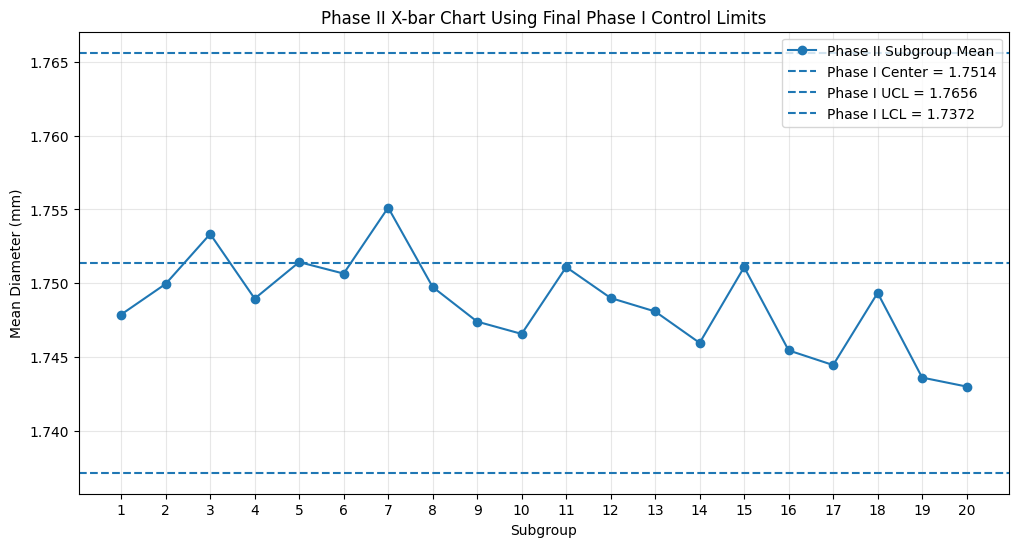

In [42]:
## Q10 Code ##

import pandas as pd
import matplotlib.pyplot as plt

# Read Phase II data
phase2 = pd.read_excel("/content/FilamentDiameter_PhaseII.xlsx")

measure_cols = ["Meas1", "Meas2", "Meas3", "Meas4", "Meas5"]

# Calculate the mean of each Phase II subgroup
phase2["Xbar"] = phase2[measure_cols].mean(axis=1)

# FINAL Phase I limits from Q7
CL = 1.7513920623
UCL = 1.7656191973
LCL = 1.7371649273

# Identify Phase II out-of-control subgroups
ooc_phase2 = phase2[
    (phase2["Xbar"] > UCL) |
    (phase2["Xbar"] < LCL)
]

print("Phase II subgroup means:")
print(phase2[["Subgroup", "Xbar"]])

print("\nOut-of-control Phase II subgroups:")
print(ooc_phase2[["Subgroup", "Xbar"]])

plt.figure(figsize=(12, 6))

plt.plot(
    phase2["Subgroup"],
    phase2["Xbar"],
    marker="o",
    label="Phase II Subgroup Mean"
)

# Keep Phase I limits fixed
plt.axhline(
    CL,
    linestyle="--",
    label=f"Phase I Center = {CL:.4f}"
)

plt.axhline(
    UCL,
    linestyle="--",
    label=f"Phase I UCL = {UCL:.4f}"
)

plt.axhline(
    LCL,
    linestyle="--",
    label=f"Phase I LCL = {LCL:.4f}"
)

plt.xlabel("Subgroup")
plt.ylabel("Mean Diameter (mm)")
plt.title("Phase II X-bar Chart Using Final Phase I Control Limits")

plt.xticks(phase2["Subgroup"])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Q11: Construct a Phase II $s$ chart. Do any subgroups plot outside the control limits?

The subgroups does not plot outside of the control limits. But there is a school of thought or some rules that would consider more than 9 points oscilating in the same side of the control chart as a out of control process

Phase I s-bar: 0.009968
Phase I UCL: 0.020823
Phase I LCL: 0.000000

Phase II subgroup standard deviations:
    Subgroup         s
0          1  0.009891
1          2  0.002919
2          3  0.004450
3          4  0.006248
4          5  0.001774
5          6  0.005572
6          7  0.003638
7          8  0.009497
8          9  0.005629
9         10  0.007646
10        11  0.004195
11        12  0.005601
12        13  0.009889
13        14  0.003761
14        15  0.004545
15        16  0.006612
16        17  0.006243
17        18  0.004935
18        19  0.007159
19        20  0.007219

Out-of-control Phase II subgroups:
Empty DataFrame
Columns: [Subgroup, s]
Index: []


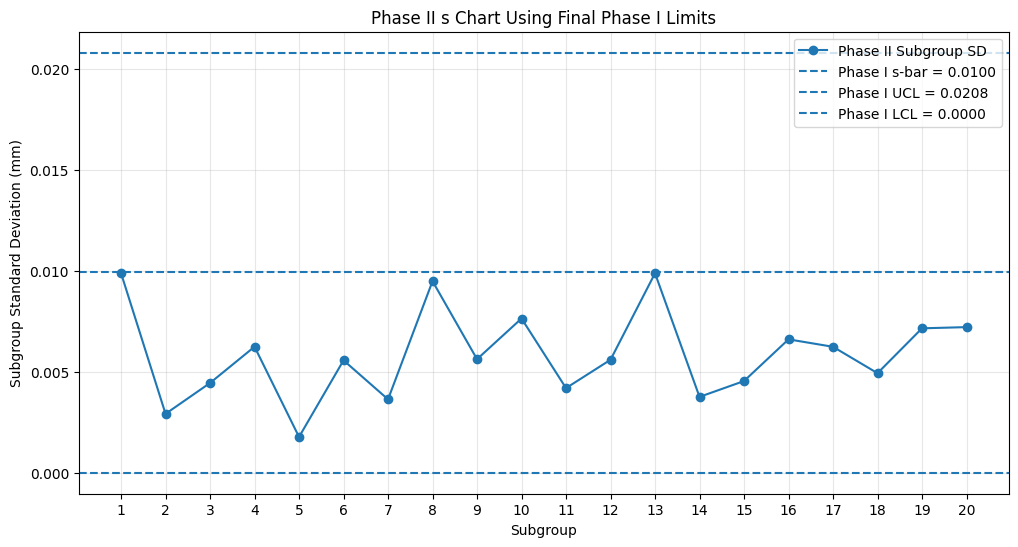

In [44]:
## Q11 Code ##

import pandas as pd
import matplotlib.pyplot as plt

# Phase II data
phase2 = pd.read_excel("/content/FilamentDiameter_PhaseII.xlsx")

measure_cols = ["Meas1", "Meas2", "Meas3", "Meas4", "Meas5"]

# Calculate subgroup sample standard deviations
phase2["s"] = phase2[measure_cols].std(axis=1, ddof=1)

# Final Phase I s-chart values from Q7
s_bar_phase1 = 0.009968
B3 = 0
B4 = 2.089

CL_s = s_bar_phase1
UCL_s = B4 * s_bar_phase1
LCL_s = B3 * s_bar_phase1

# Find OOC Phase II subgroups
ooc_s_phase2 = phase2[
    (phase2["s"] > UCL_s) |
    (phase2["s"] < LCL_s)
]

print(f"Phase I s-bar: {CL_s:.6f}")
print(f"Phase I UCL: {UCL_s:.6f}")
print(f"Phase I LCL: {LCL_s:.6f}")

print("\nPhase II subgroup standard deviations:")
print(phase2[["Subgroup", "s"]])

print("\nOut-of-control Phase II subgroups:")
print(ooc_s_phase2[["Subgroup", "s"]])


plt.figure(figsize=(12, 6))

plt.plot(
    phase2["Subgroup"],
    phase2["s"],
    marker="o",
    label="Phase II Subgroup SD"
)

plt.axhline(
    CL_s,
    linestyle="--",
    label=f"Phase I s-bar = {CL_s:.4f}"
)

plt.axhline(
    UCL_s,
    linestyle="--",
    label=f"Phase I UCL = {UCL_s:.4f}"
)

plt.axhline(
    LCL_s,
    linestyle="--",
    label=f"Phase I LCL = {LCL_s:.4f}"
)



plt.xlabel("Subgroup")
plt.ylabel("Subgroup Standard Deviation (mm)")
plt.title("Phase II s Chart Using Final Phase I Limits")
plt.xticks(phase2["Subgroup"])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Q12: Provide an overview of the results that the plant manager can provide the Vice President of Operations. Do they need to completely overhaul line 3 or is it salvagable?

After performing a corrective action on line 3, the results demonstrated enough evidence that the process is producing parts in conformance with the design and the control charts demonstrated its stability with a mean of 1.75 and a subgroup variation of no more than 0.01.